# Panel VAR Analysis — Utilization × Volatility

**Panel:** 29 CSUs across 10 chains, 551 daily observations (June 2024 – December 2025)  
**Variables:** Utilization (leverage proxy), Collateral basket volatility (14-day rolling)  
**Method:** Fixed-effects VAR with Cholesky identification, bootstrap confidence intervals

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

## 1. Load and Filter Data

In [2]:
df = pd.read_excel('../data/analysis/vol_util_panel.xlsx', sheet_name='panel_data')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['csu', 'date'])

print(f"Raw panel: {len(df):,} obs, {df['csu'].nunique()} CSUs")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"\nAll CSUs:")
for csu in sorted(df['csu'].unique()):
    n = len(df[df['csu'] == csu])
    u = df[df['csu'] == csu]['utilization'].mean()
    print(f"  {csu}: {n} obs, mean util={u:.3f}")

Raw panel: 18,063 obs, 35 CSUs
Date range: 2024-06-29 to 2025-12-31

All CSUs:
  aave_v3_arbitrum: 551 obs, mean util=0.418
  aave_v3_avalanche: 549 obs, mean util=0.341
  aave_v3_base: 551 obs, mean util=0.457
  aave_v3_binance: 550 obs, mean util=0.332
  aave_v3_ethereum: 551 obs, mean util=0.428
  aave_v3_linea: 323 obs, mean util=0.415
  aave_v3_optimism: 551 obs, mean util=0.380
  aave_v3_polygon: 551 obs, mean util=0.317
  aave_v3_scroll: 70 obs, mean util=0.415
  aave_v3_xdai: 550 obs, mean util=0.250
  benqi_lending_avalanche: 548 obs, mean util=0.645
  compound_v3_arb_usdc: 551 obs, mean util=0.301
  compound_v3_arb_usdc_e: 551 obs, mean util=0.274
  compound_v3_arb_usdt: 551 obs, mean util=0.105
  compound_v3_arb_weth: 551 obs, mean util=0.418
  compound_v3_base_aero: 446 obs, mean util=0.184
  compound_v3_base_usdbc: 551 obs, mean util=0.000
  compound_v3_base_usdc: 551 obs, mean util=0.306
  compound_v3_base_weth: 551 obs, mean util=0.451
  compound_v3_eth_usdc: 551 obs, me

In [3]:
# Quality filters
# 1. Exclude CSUs with near-zero utilization (no meaningful leverage)
exclude_csus = [
    'fluid_lending_arbitrum',   # util ≈ 0.000
    'fluid_lending_ethereum',   # util ≈ 0.000
    'gearbox_ethereum',         # util ≈ 0.000
    'sumermoney_meter',         # util ≈ 0.003
    'compound_v3_base_usdbc',   # util ≈ 0.000
]

# 2. Require at least 300 observations (~10 months)
min_observations = 300

df = df[~df['csu'].isin(exclude_csus)]
csu_counts = df.groupby('csu').size()
short_csus = csu_counts[csu_counts < min_observations].index.tolist()
print(f"Excluding for short series (<{min_observations} obs): {short_csus}")
df = df[~df['csu'].isin(short_csus)]

# Forward-fill missing volatility within each CSU
df['volatility'] = df.groupby('csu')['volatility'].ffill().bfill()
df = df.dropna(subset=['utilization', 'volatility'])

print(f"\nFiltered panel: {len(df):,} obs, {df['csu'].nunique()} CSUs")

Excluding for short series (<300 obs): ['aave_v3_scroll']

Filtered panel: 15,328 obs, 29 CSUs


## 2. Define Subsamples

**Pooled architecture** — All assets share one collateral pool (Aave V3, Benqi, Moonwell, SparkLend, Venus).  
**Isolated architecture** — Each market has a single base (borrowed) asset with its own collateral set (Compound V3).

Within isolated markets, we further split by **base asset type**:
- **Stablecoin base** (USDC, USDT, USDS): Borrowers take stablecoin loans against volatile collateral
- **Volatile base** (WETH, wstETH, AERO): Borrowers take volatile-asset loans against other volatile collateral

In [4]:
pooled_csus = [
    'aave_v3_arbitrum', 'aave_v3_avalanche', 'aave_v3_base',
    'aave_v3_binance', 'aave_v3_ethereum', 'aave_v3_linea',
    'aave_v3_optimism', 'aave_v3_polygon', 'aave_v3_xdai',
    'benqi_lending_avalanche', 'moonwell_lending_base',
    'sparklend_ethereum', 'venus_core_pool_binance',
]

isolated_csus = [
    'compound_v3_arb_usdc', 'compound_v3_arb_usdc_e',
    'compound_v3_arb_usdt', 'compound_v3_arb_weth',
    'compound_v3_base_aero', 'compound_v3_base_usdc',
    'compound_v3_base_weth', 'compound_v3_eth_usdc',
    'compound_v3_eth_usds', 'compound_v3_eth_usdt',
    'compound_v3_eth_weth', 'compound_v3_eth_wsteth',
    'compound_v3_op_usdc', 'compound_v3_op_usdt',
    'compound_v3_op_weth', 'compound_v3_poly_usdc',
]

stablecoin_markets = [
    'compound_v3_arb_usdc', 'compound_v3_arb_usdc_e',
    'compound_v3_arb_usdt', 'compound_v3_base_usdc',
    'compound_v3_eth_usdc', 'compound_v3_eth_usds',
    'compound_v3_eth_usdt', 'compound_v3_op_usdc',
    'compound_v3_op_usdt', 'compound_v3_poly_usdc',
]

volatile_asset_markets = [
    'compound_v3_arb_weth', 'compound_v3_base_aero',
    'compound_v3_base_weth', 'compound_v3_eth_weth',
    'compound_v3_eth_wsteth', 'compound_v3_op_weth',
]

# Filter to CSUs actually present in the data
valid = set(df['csu'].unique())
pooled_csus = [c for c in pooled_csus if c in valid]
isolated_csus = [c for c in isolated_csus if c in valid]
stablecoin_markets = [c for c in stablecoin_markets if c in valid]
volatile_asset_markets = [c for c in volatile_asset_markets if c in valid]

print(f"Pooled:     {len(pooled_csus)} CSUs")
print(f"Isolated:   {len(isolated_csus)} CSUs")
print(f"  Stable:   {len(stablecoin_markets)} CSUs")
print(f"  Volatile: {len(volatile_asset_markets)} CSUs")

Pooled:     13 CSUs
Isolated:   16 CSUs
  Stable:   10 CSUs
  Volatile: 6 CSUs


## 3. Summary Statistics

In [5]:
samples = {
    'Full Sample': pooled_csus + isolated_csus,
    'Pooled': pooled_csus,
    'Isolated': isolated_csus,
    'Stable Base': stablecoin_markets,
    'Volatile Base': volatile_asset_markets,
}

rows = []
for label, csus in samples.items():
    sub = df[df['csu'].isin(csus)]
    rows.append({
        'Sample': label,
        'N (CSUs)': sub['csu'].nunique(),
        'T (dates)': sub['date'].nunique(),
        'Obs': len(sub),
        'Util Mean': sub['utilization'].mean(),
        'Util SD': sub['utilization'].std(),
        'Vol Mean': sub['volatility'].mean(),
        'Vol SD': sub['volatility'].std(),
    })

summary_df = pd.DataFrame(rows)
summary_df.style.format({
    'Obs': '{:,.0f}',
    'Util Mean': '{:.3f}', 'Util SD': '{:.3f}',
    'Vol Mean': '{:.4f}', 'Vol SD': '{:.4f}',
}).set_caption('Table 1: Panel Summary Statistics')

,Sample,N (CSUs),T (dates),Obs,Util Mean,Util SD,Vol Mean,Vol SD
0,Full Sample,29,551,"15,328",0.356,0.125,0.0209,0.0123
1,Pooled,13,551,"6,928",0.401,0.116,0.0197,0.0105
2,Isolated,16,551,"8,400",0.319,0.121,0.0218,0.0135
3,Stable Base,10,551,"5,391",0.291,0.103,0.0153,0.0074
4,Volatile Base,6,551,"3,009",0.370,0.133,0.0336,0.0141


## 4. Panel VAR Estimation

**Procedure:**
1. Within-transform (demean by CSU) to remove fixed effects
2. Estimate VAR on the demeaned panel
3. Select lag order via BIC (capped at 5)
4. Orthogonalized IRF via Cholesky decomposition (ordering: utilization first, volatility second)
5. 95% bootstrap confidence intervals (500 replications, residual resampling)

In [6]:
def run_panel_var(df, csus, label, max_lags=10, irf_periods=20, n_boot=500):
    """
    Run fixed-effects Panel VAR on a subsample.
    Returns dict with results, IRFs, bootstrap CIs, Granger tests.
    """
    sub = df[df['csu'].isin(csus)].copy()
    
    # Fixed effects: within-transformation (demean by CSU)
    sub['util_fe'] = sub.groupby('csu')['utilization'].transform(lambda x: x - x.mean())
    sub['vol_fe'] = sub.groupby('csu')['volatility'].transform(lambda x: x - x.mean())
    panel = sub[['util_fe', 'vol_fe']].dropna()
    
    # Fit VAR with BIC-selected lags
    model = VAR(panel)
    try:
        lo = model.select_order(maxlags=min(max_lags, len(panel) // 3))
        optimal = max(1, min(lo.bic, 5))
        print(f"  Lag selection — AIC: {lo.aic}, BIC: {lo.bic}, HQIC: {lo.hqic} → using {optimal}")
    except:
        optimal = 2
        print(f"  Lag selection failed, using {optimal}")
    
    results = model.fit(optimal)
    
    # Orthogonalized IRFs
    irf = results.irf(irf_periods)
    irf_orth = irf.orth_irfs  # shape: (periods+1, 2, 2)
    
    # Bootstrap CIs (residual resampling)
    rng = np.random.RandomState(42)
    boot_irfs = []
    resids = results.resid.values
    fitted = results.fittedvalues.values
    
    for _ in range(n_boot):
        idx = rng.choice(len(resids), size=len(resids), replace=True)
        boot_data = fitted + resids[idx]
        try:
            br = VAR(pd.DataFrame(boot_data, columns=panel.columns)).fit(optimal)
            boot_irfs.append(br.irf(irf_periods).orth_irfs)
        except:
            continue
    
    ci_lo = ci_hi = None
    if len(boot_irfs) > 50:
        ba = np.array(boot_irfs)
        ci_lo = np.percentile(ba, 2.5, axis=0)
        ci_hi = np.percentile(ba, 97.5, axis=0)
        print(f"  Bootstrap: {len(boot_irfs)}/{n_boot} successful replications")
    
    # Granger causality
    gc = {}
    try:
        gc_uv = results.test_causality('vol_fe', ['util_fe'], kind='f')
        gc['util→vol'] = {'F': gc_uv.test_statistic, 'p': gc_uv.pvalue}
    except: pass
    try:
        gc_vu = results.test_causality('util_fe', ['vol_fe'], kind='f')
        gc['vol→util'] = {'F': gc_vu.test_statistic, 'p': gc_vu.pvalue}
    except: pass
    
    return {
        'label': label,
        'results': results,
        'irf_orth': irf_orth,
        'ci_lo': ci_lo,
        'ci_hi': ci_hi,
        'gc': gc,
        'n_csus': sub['csu'].nunique(),
        'n_obs': len(sub),
        'lags': optimal,
    }

In [7]:
# Run all five analyses
all_results = {}
for label, csus in samples.items():
    print(f"\n{'='*60}")
    print(f"  {label} ({len(csus)} CSUs)")
    print(f"{'='*60}")
    all_results[label] = run_panel_var(df, csus, label)


  Full Sample (29 CSUs)


  Lag selection — AIC: 10, BIC: 10, HQIC: 10 → using 5


  Bootstrap: 500/500 successful replications

  Pooled (13 CSUs)
  Lag selection — AIC: 10, BIC: 8, HQIC: 9 → using 5


  Bootstrap: 500/500 successful replications

  Isolated (16 CSUs)
  Lag selection — AIC: 10, BIC: 9, HQIC: 10 → using 5


  Bootstrap: 500/500 successful replications

  Stable Base (10 CSUs)
  Lag selection — AIC: 10, BIC: 8, HQIC: 9 → using 5


  Bootstrap: 500/500 successful replications

  Volatile Base (6 CSUs)
  Lag selection — AIC: 10, BIC: 4, HQIC: 9 → using 4


  Bootstrap: 500/500 successful replications


## 5. Granger Causality Tests

In [8]:
def stars(p):
    if p < 0.01: return '***'
    if p < 0.05: return '**'
    if p < 0.10: return '*'
    return ''

gc_rows = []
for label, res in all_results.items():
    row = {'Sample': label, 'Lags': res['lags']}
    gc = res['gc']
    if 'util→vol' in gc:
        row['F (U→V)'] = f"{gc['util→vol']['F']:.3f}"
        row['p (U→V)'] = f"{gc['util→vol']['p']:.4f}{stars(gc['util→vol']['p'])}"
    if 'vol→util' in gc:
        row['F (V→U)'] = f"{gc['vol→util']['F']:.3f}"
        row['p (V→U)'] = f"{gc['vol→util']['p']:.4f}{stars(gc['vol→util']['p'])}"
    gc_rows.append(row)

gc_df = pd.DataFrame(gc_rows)
print("Table 2: Granger Causality Tests")
print("="*70)
print(gc_df.to_string(index=False))
print("\n*** p<0.01, ** p<0.05, * p<0.10")

Table 2: Granger Causality Tests
       Sample  Lags F (U→V)   p (U→V) F (V→U)   p (V→U)
  Full Sample     5   0.858    0.5087   2.586  0.0241**
       Pooled     5   0.509    0.7699   1.321    0.2519
     Isolated     5   0.597    0.7022   2.587  0.0240**
  Stable Base     5   4.597 0.0003***   3.244 0.0063***
Volatile Base     4   1.718    0.1430   3.625 0.0059***

*** p<0.01, ** p<0.05, * p<0.10


## 6. IRF: Utilization Shock → Volatility Response

The Cholesky ordering places utilization first, so a utilization shock is identified as an orthogonalized innovation to utilization that is uncorrelated with contemporaneous volatility.

In [9]:
def plot_irf(res, impulse_idx, response_idx, title, ax=None, color='blue'):
    """Plot a single IRF path with bootstrap CI."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    
    vals = res['irf_orth'][:, impulse_idx, response_idx]
    periods = range(len(vals))
    
    ax.plot(periods, vals, color=color, lw=2.5)
    if res['ci_lo'] is not None:
        ax.fill_between(periods,
                        res['ci_lo'][:, impulse_idx, response_idx],
                        res['ci_hi'][:, impulse_idx, response_idx],
                        alpha=0.2, color=color)
    ax.axhline(0, color='black', ls='--', lw=0.8)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Days After Shock')
    ax.set_ylabel('Response')
    return ax

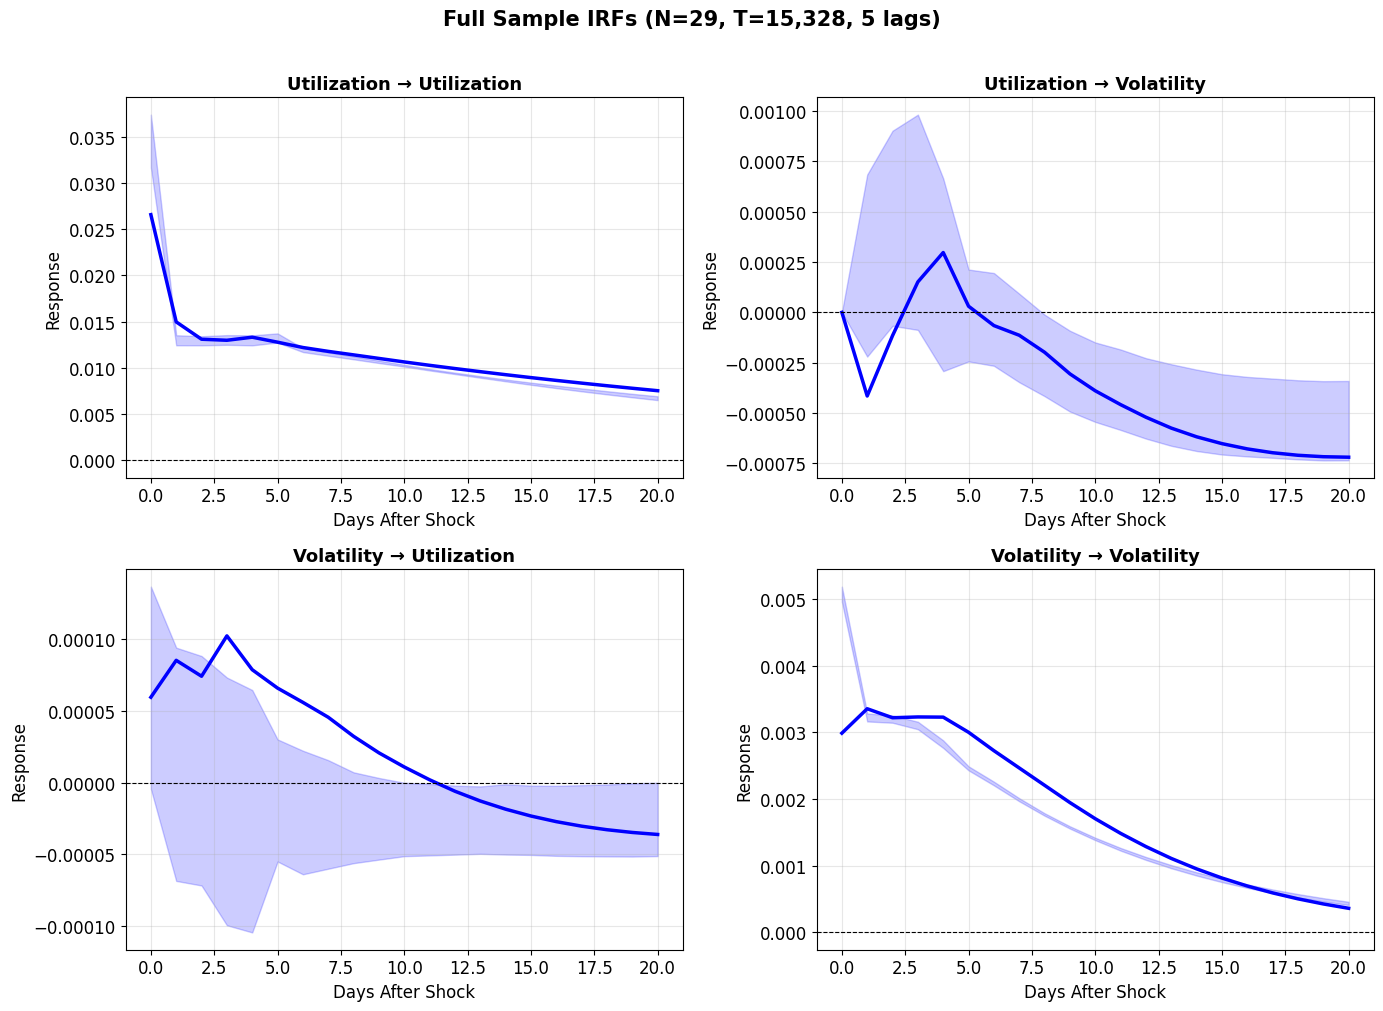

In [10]:
# Full sample: 2x2 IRF grid
res = all_results['Full Sample']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

plot_irf(res, 0, 0, 'Utilization → Utilization', axes[0,0])
plot_irf(res, 0, 1, 'Utilization → Volatility', axes[0,1])
plot_irf(res, 1, 0, 'Volatility → Utilization', axes[1,0])
plot_irf(res, 1, 1, 'Volatility → Volatility', axes[1,1])

fig.suptitle(f"Full Sample IRFs (N={res['n_csus']}, T={res['n_obs']:,}, {res['lags']} lags)",
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 7. Key Finding: Opposite Signs by Base Asset Type

The central empirical result: the response of collateral volatility to a utilization shock **reverses sign** depending on the base asset type of the Compound V3 isolated market.

- **Stablecoin base markets** (USDC/USDT/USDS): Utilization ↑ → Volatility **↓** (negative)
- **Volatile base markets** (WETH/wstETH/AERO): Utilization ↑ → Volatility **↑** (positive)

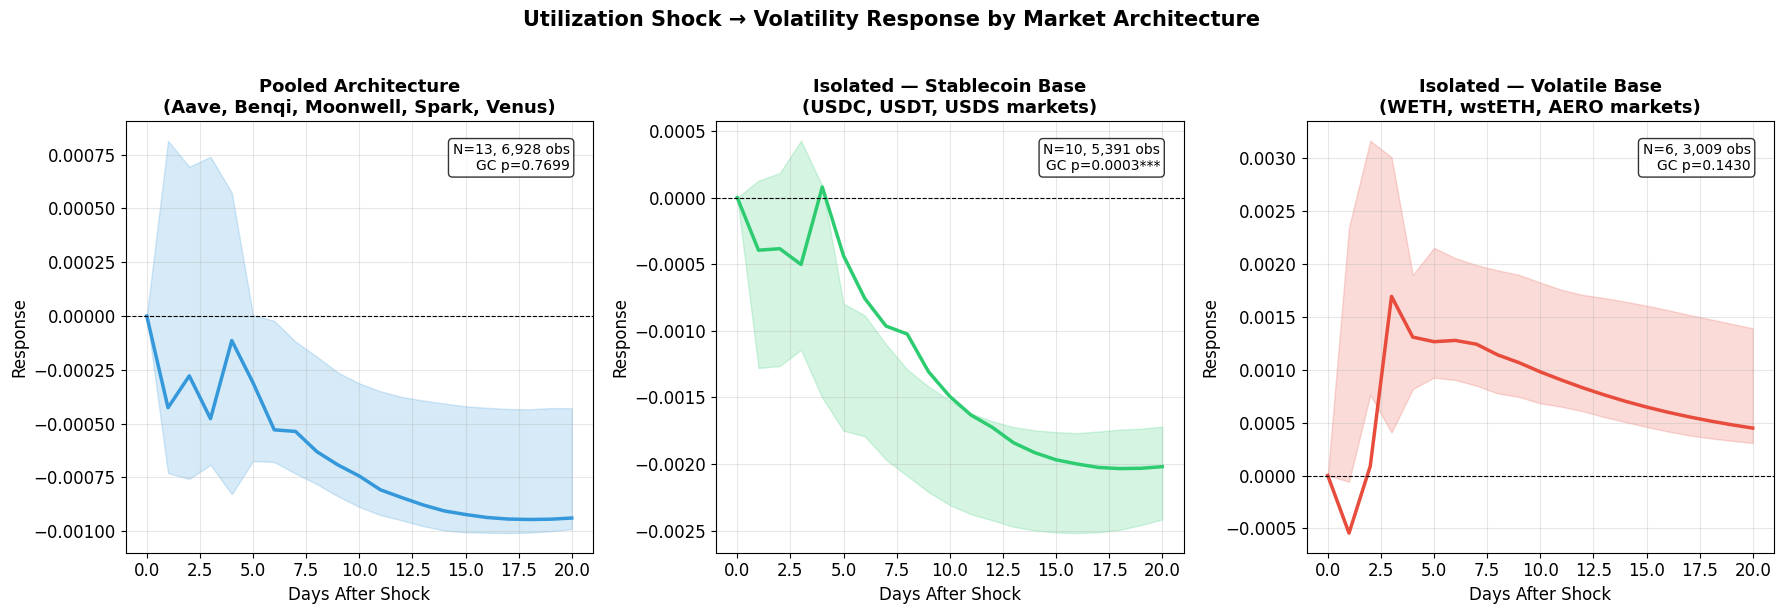

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

specs = [
    ('Pooled', 'Pooled Architecture\n(Aave, Benqi, Moonwell, Spark, Venus)', '#3498db'),
    ('Stable Base', 'Isolated — Stablecoin Base\n(USDC, USDT, USDS markets)', '#2ecc71'),
    ('Volatile Base', 'Isolated — Volatile Base\n(WETH, wstETH, AERO markets)', '#e74c3c'),
]

for ax, (key, title, color) in zip(axes, specs):
    res = all_results[key]
    plot_irf(res, 0, 1, title, ax, color)
    
    # Annotate with Granger p-value
    gc = res['gc']
    if 'util→vol' in gc:
        p = gc['util→vol']['p']
        ax.text(0.95, 0.95, f"N={res['n_csus']}, {res['n_obs']:,} obs\nGC p={p:.4f}{stars(p)}",
                transform=ax.transAxes, fontsize=10, va='top', ha='right',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

fig.suptitle('Utilization Shock → Volatility Response by Market Architecture',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../results/figure_key_irf_comparison.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

## 8. IRF Summary Table

In [12]:
irf_rows = []
for label, res in all_results.items():
    irf_uv = res['irf_orth'][:, 0, 1]  # util → vol
    peak_idx = int(np.argmax(np.abs(irf_uv)))
    cumul = np.sum(irf_uv)
    
    # Count significant horizons
    n_sig = 0
    if res['ci_lo'] is not None:
        for h in range(len(irf_uv)):
            lo = res['ci_lo'][h, 0, 1]
            hi = res['ci_hi'][h, 0, 1]
            if lo > 0 or hi < 0:
                n_sig += 1
    
    irf_rows.append({
        'Sample': label,
        'N': res['n_csus'],
        'Obs': f"{res['n_obs']:,}",
        'Impact (t=1)': f"{irf_uv[1]:.5f}",
        'Peak': f"{irf_uv[peak_idx]:.5f}",
        'Peak Period': f"t+{peak_idx}",
        'Cumulative': f"{cumul:.5f}",
        'Sign': '+' if cumul > 0 else '−',
        'Sig Horizons': f"{n_sig}/21",
    })

irf_df = pd.DataFrame(irf_rows)
print("Table 3: IRF Summary — Utilization Shock → Volatility")
print("="*90)
print(irf_df.to_string(index=False))

Table 3: IRF Summary — Utilization Shock → Volatility
       Sample  N    Obs Impact (t=1)     Peak Peak Period Cumulative Sign Sig Horizons
  Full Sample 29 15,328     -0.00042 -0.00072        t+20   -0.00747    −        13/21
       Pooled 13  6,928     -0.00043 -0.00095        t+18   -0.01381    −        15/21
     Isolated 16  8,400     -0.00040 -0.00067        t+20   -0.00356    −        11/21
  Stable Base 10  5,391     -0.00039 -0.00203        t+18   -0.02637    −        16/21
Volatile Base  6  3,009     -0.00054  0.00169         t+3    0.01594    +        19/21


## 9. Detailed IRF Values with Significance

In [13]:
for label in ['Stable Base', 'Volatile Base']:
    res = all_results[label]
    irf_uv = res['irf_orth'][:, 0, 1]
    
    print(f"\n{'='*60}")
    print(f"  {label}: Utilization → Volatility")
    print(f"{'='*60}")
    print(f"{'Horizon':>8}  {'IRF':>10}  {'95% CI':>24}  {'Sig':>4}")
    print(f"{'-'*52}")
    
    for h in range(min(21, len(irf_uv))):
        ci_str = ''
        sig = ''
        if res['ci_lo'] is not None:
            lo = res['ci_lo'][h, 0, 1]
            hi = res['ci_hi'][h, 0, 1]
            ci_str = f"[{lo:9.6f}, {hi:9.6f}]"
            if lo > 0 or hi < 0:
                sig = ' *'
        print(f"  t+{h:2d}    {irf_uv[h]:10.6f}  {ci_str}  {sig}")


  Stable Base: Utilization → Volatility
 Horizon         IRF                    95% CI   Sig
----------------------------------------------------
  t+ 0      0.000000  [ 0.000000,  0.000000]  
  t+ 1     -0.000395  [-0.001279,  0.000128]  
  t+ 2     -0.000383  [-0.001264,  0.000184]  
  t+ 3     -0.000501  [-0.001142,  0.000427]  
  t+ 4      0.000080  [-0.001502,  0.000088]  
  t+ 5     -0.000436  [-0.001750, -0.000796]   *
  t+ 6     -0.000757  [-0.001791, -0.000884]   *
  t+ 7     -0.000964  [-0.001967, -0.001102]   *
  t+ 8     -0.001024  [-0.002089, -0.001290]   *
  t+ 9     -0.001307  [-0.002210, -0.001418]   *
  t+10     -0.001492  [-0.002307, -0.001523]   *
  t+11     -0.001632  [-0.002377, -0.001620]   *
  t+12     -0.001724  [-0.002422, -0.001678]   *
  t+13     -0.001840  [-0.002471, -0.001723]   *
  t+14     -0.001914  [-0.002498, -0.001747]   *
  t+15     -0.001968  [-0.002514, -0.001761]   *
  t+16     -0.002000  [-0.002518, -0.001768]   *
  t+17     -0.002026  [-0.0025

## 10. Subsample Overlay Plot

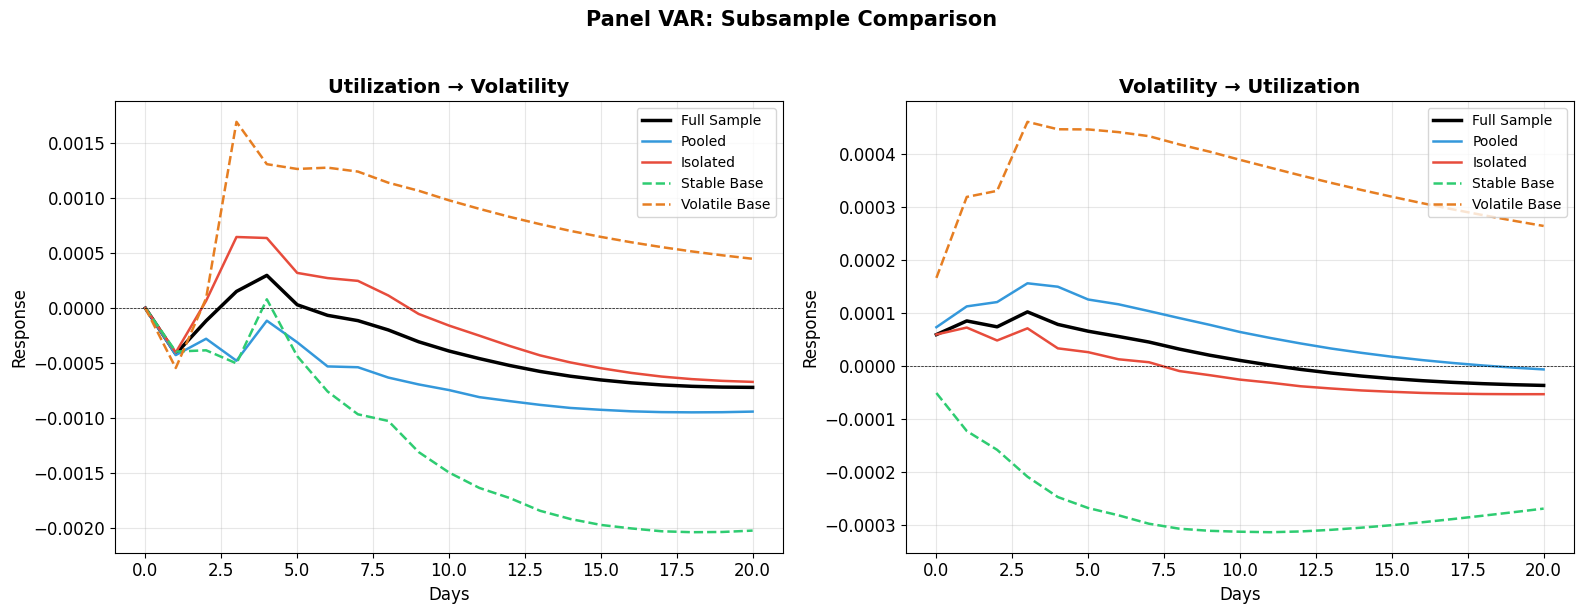

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

styles = {
    'Full Sample':    ('black',      2.5, '-'),
    'Pooled':         ('#3498db',    1.8, '-'),
    'Isolated':       ('#e74c3c',    1.8, '-'),
    'Stable Base':    ('#2ecc71',    1.8, '--'),
    'Volatile Base':  ('#e67e22',    1.8, '--'),
}

# Left: util → vol
ax = axes[0]
for label, res in all_results.items():
    c, lw, ls = styles[label]
    vals = res['irf_orth'][:, 0, 1]
    ax.plot(range(len(vals)), vals, color=c, lw=lw, ls=ls, label=label)
ax.axhline(0, color='black', ls='--', lw=0.5)
ax.set_title('Utilization → Volatility', fontsize=14, fontweight='bold')
ax.set_xlabel('Days')
ax.set_ylabel('Response')
ax.legend(fontsize=10)

# Right: vol → util
ax = axes[1]
for label, res in all_results.items():
    c, lw, ls = styles[label]
    vals = res['irf_orth'][:, 1, 0]
    ax.plot(range(len(vals)), vals, color=c, lw=lw, ls=ls, label=label)
ax.axhline(0, color='black', ls='--', lw=0.5)
ax.set_title('Volatility → Utilization', fontsize=14, fontweight='bold')
ax.set_xlabel('Days')
ax.set_ylabel('Response')
ax.legend(fontsize=10)

fig.suptitle('Panel VAR: Subsample Comparison', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../results/irf_subsample_comparison.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

## 11. Architecture Comparison Table

In [15]:
comp_rows = []
for label in ['Pooled', 'Isolated', 'Stable Base', 'Volatile Base']:
    res = all_results[label]
    irf_uv = res['irf_orth'][:, 0, 1]
    irf_vu = res['irf_orth'][:, 1, 0]
    gc = res['gc']
    
    comp_rows.append({
        'Sample': label,
        'N': res['n_csus'],
        'GC p (U→V)': f"{gc.get('util→vol', {}).get('p', np.nan):.4f}{stars(gc.get('util→vol', {}).get('p', 1))}",
        'GC p (V→U)': f"{gc.get('vol→util', {}).get('p', np.nan):.4f}{stars(gc.get('vol→util', {}).get('p', 1))}",
        'Cumul IRF (U→V)': f"{np.sum(irf_uv):.5f}",
        'Cumul IRF (V→U)': f"{np.sum(irf_vu):.5f}",
        'Sign (U→V)': '+' if np.sum(irf_uv) > 0 else '−',
    })

comp_df = pd.DataFrame(comp_rows)
print("Table 4: Architecture Comparison")
print("="*90)
print(comp_df.to_string(index=False))

Table 4: Architecture Comparison
       Sample  N GC p (U→V) GC p (V→U) Cumul IRF (U→V) Cumul IRF (V→U) Sign (U→V)
       Pooled 13     0.7699     0.2519        -0.01381         0.00138          −
     Isolated 16     0.7022   0.0240**        -0.00356        -0.00018          −
  Stable Base 10  0.0003***  0.0063***        -0.02637        -0.00551          −
Volatile Base  6     0.1430  0.0059***         0.01594         0.00742          +


## 12. Interpretation Summary

### Key Findings

**1. Volatility Granger-causes utilization (deleveraging channel)**  
Significant in Full Sample (p=0.024), Isolated (p=0.024), Stablecoin (p=0.006), and Volatile (p=0.006) markets. When collateral volatility rises, utilization adjusts — consistent with borrowers deleveraging or being liquidated during stress.

**2. Utilization → Volatility depends on market structure**  
Only significant in stablecoin base markets (p<0.001). The response sign reverses:
- **Stablecoin base (−):** Higher utilization is associated with subsequent *lower* collateral volatility. Consistent with procyclical leverage — borrowing expands during calm markets.
- **Volatile base (+):** Higher utilization is associated with subsequent *higher* collateral volatility. Consistent with reflexive leverage — ETH borrowing amplifies collateral price movements.

**3. Pooled vs Isolated architecture**  
Pooled protocols (Aave etc.) show a negative U→V response similar to stablecoin markets, which makes sense — their aggregate utilization is dominated by stablecoin borrowing.